In [1]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt

In [2]:
# pulizia per sicurezza

#os.system("rm *.h5")
os.system("rm summary.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

rm: cannot remove ‘summary.h5’: No such file or directory
rm: cannot remove ‘*.out’: No such file or directory


0

In [3]:
# VARIABILI DA PAPERMILL se serve (verranno sovrascritte)
pressione_atm = 1.0
moltiplicatore = 4.0
perc_water = 0.15
arricch_max =  45.553 # in percentuale
arricch_min = 5  # in percentuale
t_water = 350.0
t_fuel = 600.0
run_id = "default"

VARIABILI IMPORTANTI

In [4]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters("parametri.txt")

# --- Parametri Geometrici e Logici ---
R_CORE    = p['R_CORE']*moltiplicatore
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']
R_PIPE    = p['R_PIPE']

# --- Parametri Target e Sorgente ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']
S         = p['S']
bin_ris   = p['bin_ris']

batches   = p['batches_auto']
particles = p['particles_auto']
inactive      = p['inactive_auto']


# --- Parametri Pin/Lattice Base ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']

enrich_target = p['enrich_target']

# ==========================================
# SOVRASCRITTURA CON PARAMETRI DI PAPERMILL
# ==========================================
Pressione_funzionamento = pressione_atm * 101325  # atm in Pa
PITCH     = p['PITCH'] * moltiplicatore
mix       = perc_water
T_water   = t_water
T_resto   = t_fuel

# I valori dal txt sono in percentuale, convertiamoli in frazione
enrich_max = arricch_max / 100.0
enrich_min = arricch_min / 100.0


In [5]:
from CoolProp.CoolProp import PropsSI

def densita_mix_dinamica(T_K, P_Pa= Pressione_funzionamento, frac_mass_H2O=mix):
    # Calcolo in kg/m^3 e conversione in g/cm^3
    rho_H2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'Water') / 1000     # D sta per densità
    rho_D2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'HeavyWater') / 1000
    
    # Calcolo miscela assumendo volumi ideali additivi
    rho_mix = 1 / (frac_mass_H2O / rho_H2O + (1 - frac_mass_H2O) / rho_D2O) # Formula di additività dei volumi specifici
    return rho_mix

print(f"Densità del mix a {T_water} K e {Pressione_funzionamento/1e6} MPa: {densita_mix_dinamica(T_water, Pressione_funzionamento, mix):.4f} g/cm^3")

Densità del mix a 350.0 K e 0.101325 MPa: 1.0629 g/cm^3


MATERIALI

In [6]:
# materiale di rivestimento
cladding = openmc.Material(name='cladding')
cladding.temperature = T_resto
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material(name='water')
water.temperature = T_water
water.add_nuclide('H1', mix)
water.add_nuclide('H2', 1-mix)
water.add_element('O', 1.0)
water.set_density('g/cm3', densita_mix_dinamica(T_water)) # Usa la densità corretta
water.add_s_alpha_beta('c_D_in_D2O') 
water.add_s_alpha_beta('c_H_in_H2O') 

# aggiungo un riflettore 
reflector = openmc.Material(name='reflector')
reflector.temperature = T_resto
reflector.add_element('C', 1.0)
reflector.set_density('g/cm3', 1.75) 

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.temperature = T_resto
marker_mat.set_density('g/cm3', 1e-10) 
marker_mat.add_nuclide('He4', 1.0) 

void_air = openmc.Material(name='void_air')
void_air.temperature = T_resto
void_air.set_density('g/cm3', 1e-10) 
void_air.add_nuclide('N14', 1)

mat_target = openmc.Material(name='mat_target')
mat_target.temperature = T_resto
mat_target.add_nuclide('U235', enrich_target)
mat_target.add_nuclide('U238', 1.0 - enrich_target)
mat_target.add_nuclide('O16', 2.0)
mat_target.set_density('g/cm3', 10.96)
mat_target.volume = np.pi * (R_TARGET**2) * H_TARGET
mat_target.depletable = False

GEOMETRIA

In [7]:
# --- 0. FUNZIONI E CALCOLO NUMERO BARRE ---
import numpy as np

def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    for i in range(num_rings):
        ring_radius = i * pitch
        if ring_radius >= r_pipe and r_core >= ring_radius:
            total_pins += 1 if i == 0 else (6 * i)
    return total_pins

num_rings = int(np.ceil(R_CORE / PITCH)) + 1
n_barre = count_fuel_pins(num_rings, PITCH, R_PIPE, R_CORE)
print(f"Numero di barre di combustibile effettive: {n_barre}")

# --- 1. PIANI Z (ASSOLUTI) ---
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum')
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Piani Z Target
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))

# Superficie Sorgente
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)

# --- 2. CALCOLO DIMENSIONI E VOLUMI PER DEPLETION ---
n_rings_removed = int(np.ceil(R_PIPE / PITCH))
EDGE_PIPE_LARGE = (n_rings_removed - 0.5) * PITCH
if EDGE_PIPE_LARGE == 0: EDGE_PIPE_LARGE = PITCH

hex_core_edge = num_rings * PITCH
hex_ref_edge = hex_core_edge + REF_SIDE

# Aree esagonali base
A_core = 1.5 * np.sqrt(3) * (hex_core_edge**2)
A_pipe = 1.5 * np.sqrt(3) * (EDGE_PIPE_LARGE**2)
A_ref  = 1.5 * np.sqrt(3) * (hex_ref_edge**2)

# Assegnazione volumi
V_clad_single = np.pi * ((R_FUEL + CLAD_THICK)**2 - R_FUEL**2) * H_CORE
cladding.volume = n_barre * V_clad_single
cladding.depletable = False

V_pins_total = n_barre * np.pi * ((R_FUEL + CLAD_THICK)**2) * H_CORE
water.volume = (A_core - A_pipe) * H_CORE - V_pins_total
water.depletable = False

V_ref_side = (A_ref - A_core) * H_CORE
V_ref_bot  = A_ref * REF_BOT
reflector.volume = V_ref_side + V_ref_bot
reflector.depletable = False

# --- 3. FORME GEOMETRICHE BASE ---
EDGE_FUEL = R_FUEL
EDGE_CLAD = R_FUEL + CLAD_THICK

hex_fuel_prism = openmc.model.hexagonal_prism(edge_length=EDGE_FUEL, orientation='x')
hex_clad_prism = openmc.model.hexagonal_prism(edge_length=EDGE_CLAD, orientation='x')
hex_pipe_prism = openmc.model.hexagonal_prism(edge_length=EDGE_PIPE_LARGE, orientation='x')
cyl_target = openmc.ZCylinder(r=R_TARGET)

# --- 4. UNIVERSI COMBUSTIBILE ---
fuel_mats = []
fuel_universes = []
V_single_pin = np.pi * (R_FUEL**2) * H_CORE

for i in range(num_rings):
    if num_rings > 1:
        e_i = enrich_max - (enrich_max - enrich_min) * (i / (num_rings - 1))
    else:
        e_i = enrich_max

    f = openmc.Material(name=f'fuel_ring_{i}')
    f.temperature = T_resto
    f.add_nuclide('U235', e_i)
    f.add_nuclide('U238', 1.0 - e_i)
    f.add_nuclide('O16', 2.0)
    f.set_density('g/cm3', 10.96)
    
    ring_radius = i * PITCH
    if ring_radius >= R_PIPE and ring_radius <= R_CORE: 
        n_pins_in_ring = 6 * i if i > 0 else 1
        f.volume = n_pins_in_ring * V_single_pin
        f.depletable = True
    else:
        f.depletable = False

    fuel_mats.append(f)
    
    c_f = openmc.Cell(fill=f, region=hex_fuel_prism)
    c_c = openmc.Cell(fill=cladding, region=hex_clad_prism & ~hex_fuel_prism)
    c_w = openmc.Cell(fill=water, region=~hex_clad_prism)
    fuel_universes.append(openmc.Universe(cells=[c_f, c_c, c_w]))

# --- 5. ESPORTAZIONE MATERIALI ---
materials = openmc.Materials(fuel_mats + [cladding, water, reflector, marker_mat, void_air, mat_target])

materials.export_to_xml()

# --- 6. LATTICE E ASSEMBLAGGIO FINALE ---
c_water_full = openmc.Cell(fill=water)
u_water = openmc.Universe(cells=[c_water_full])

lattice_universes = []
for i in range(num_rings):
    if i == 0:
        lattice_universes.append([fuel_universes[i]])
    else:
        lattice_universes.append([fuel_universes[i]] * (6 * i))

lattice = openmc.HexLattice(name='core_hex_lattice')
lattice.center = (0.0, 0.0)
lattice.pitch = (PITCH,)
lattice.outer = u_water
lattice.universes = lattice_universes[::-1] 
lattice.orientation = 'x'

prism_core = openmc.model.hexagonal_prism(edge_length=hex_core_edge, orientation='x')
prism_reflector = openmc.model.hexagonal_prism(edge_length=hex_ref_edge, orientation='x', boundary_type='vacuum')

region_core = prism_core & ~hex_pipe_prism & +z_bot_core & -z_top_core
c_main_core = openmc.Cell(fill=lattice, region=region_core)

region_central_hex_total = hex_pipe_prism & +z_bot_core & -z_top_core
region_target_solid = region_central_hex_total & -cyl_target & +z_tgt_bot & -z_tgt_top
region_void_gap = region_central_hex_total & ~region_target_solid

c_target = openmc.Cell(fill=mat_target, region=region_target_solid)
c_void_gap = openmc.Cell(fill=void_air, region=region_void_gap) 

region_ref_side = prism_reflector & ~prism_core & +z_bot_core & -z_top_core
c_ref_side = openmc.Cell(fill=reflector, region=region_ref_side)

region_ref_bot = prism_reflector & +z_bot_ref & -z_bot_core
c_ref_bot = openmc.Cell(fill=reflector, region=region_ref_bot)

c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)
region_top = prism_reflector & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=void_air, region=region_top)

all_cells = [c_main_core, c_target, c_void_gap, c_ref_side, c_ref_bot, c_source_marker, c_top_void]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()
print("Geometria generata correttamente.")

Numero di barre di combustibile effettive: 396
Geometria generata correttamente.


/raid1/users/rbossi/miniforge3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:121: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


PLOTTING


VISUALIZZAZIONE GEOMETRIA

1. VISTA DALL'ALTO (Piano XY nel Core)


/raid1/users/rbossi/miniforge3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(


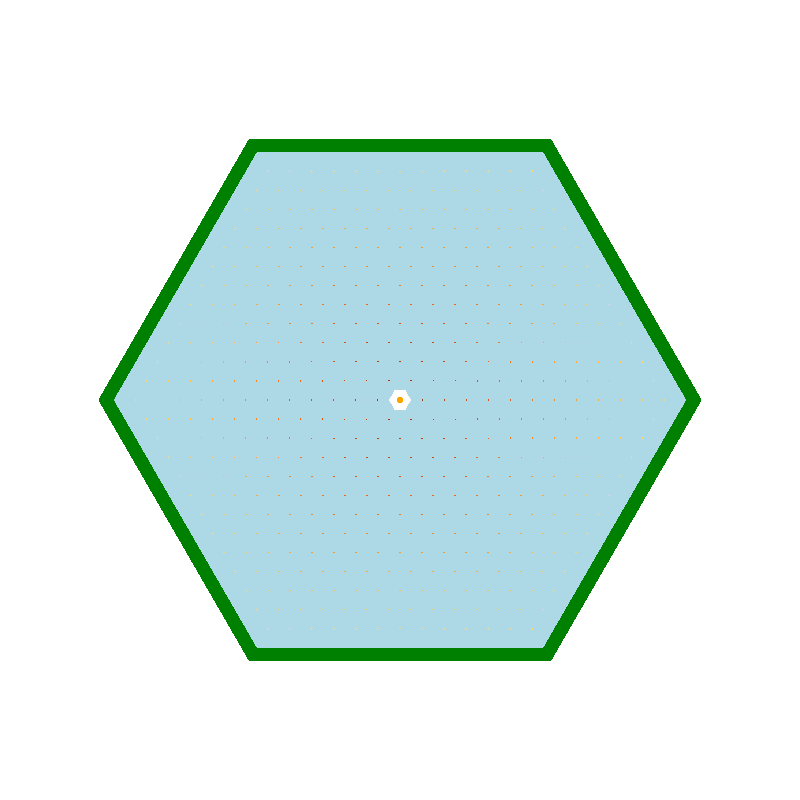

2. VISTA LATERALE (Piano XZ)


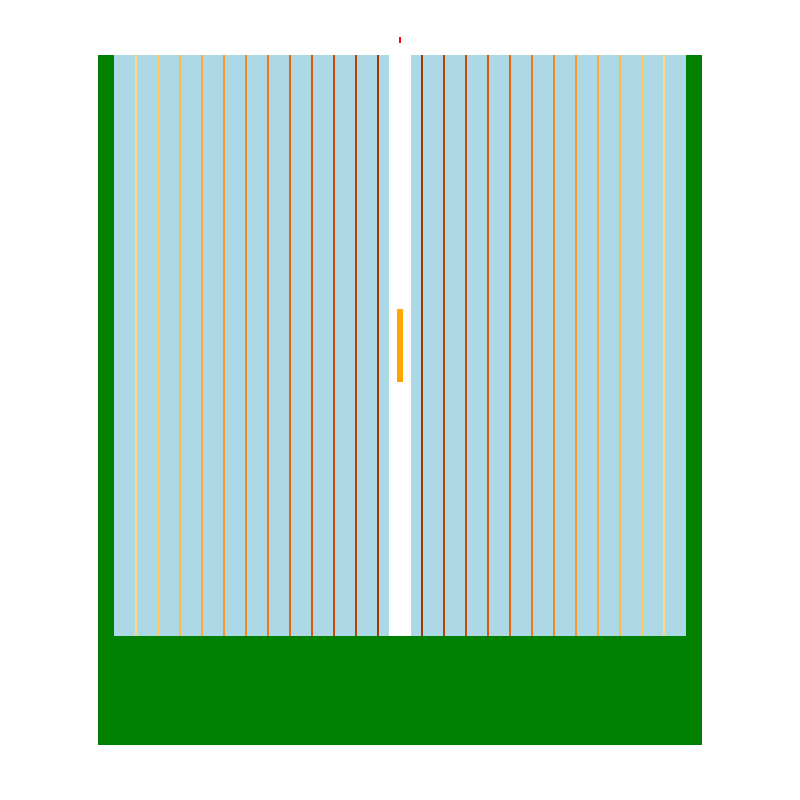

In [8]:
color_map = {
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red' ,     # Marker sorgente
    void_air: 'white',      # Vuoto (aria)
    mat_target: 'orange'   # Target
}

cmap = plt.get_cmap('YlOrBr')

for i, f in enumerate(fuel_mats):
    if num_rings > 1:
        # Normalizziamo l'indice: 0 (centro, max arricchimento) -> 1 (esterno, min arricchimento)
        norm_val = i / (num_rings - 1)
    else:
        norm_val = 0.5
        
    rgba = cmap(0.9 - norm_val * 0.6)
    
    # OpenMC richiede tuple RGB con valori interi 0-255
    rgb_color = (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
    color_map[f] = rgb_color

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

SETTINGS FIXED

In [9]:
# 1. Caricamento spettro di leakage (Step 1)
data_e = np.loadtxt("target/photoneutrons_energy.txt", skiprows=1)
energy_dist = openmc.stats.Tabular(data_e[:,0], data_e[:,1], interpolation='linear-linear')

# 2. Definizione spaziale sulla SUPERFICIE (r fissato a R_TARGET)
# Usiamo Discrete([R_TARGET], [1.0]) per forzare la nascita sul raggio esterno
r_dist = openmc.stats.Discrete([R_TARGET], [1.0])
phi_dist = openmc.stats.Uniform(0.0, 2*np.pi)
z_dist = openmc.stats.Uniform(z_mid - (H_TARGET / 2.0), z_mid + (H_TARGET / 2.0))

spatial_dist = openmc.stats.CylindricalIndependent(r_dist, phi_dist, z_dist)

# 3. Sorgente finale
source = openmc.IndependentSource()
source.space = spatial_dist
source.energy = energy_dist
source.angle = openmc.stats.Isotropic() # Oppure la distribuzione angolare corretta se la hai
source.particle = 'neutron'

# Impostazioni di simulazione
settings = openmc.Settings()

settings.max_lost_particles = 50

settings.batches = batches
settings.particles = particles
settings.run_mode = 'fixed source'

settings.temperature = {'method': 'interpolation'}

settings.max_collisions = 1000

settings.source = source

settings.photon_transport = False
settings.photonuclear_physics = False
settings.create_fission_neutrons = True

settings.export_to_xml()

# METTI TRACKING DEI NEUTRONI

TALLIES

In [10]:
tallies = openmc.Tallies()
#
## --- A. MESH E TALLY ASSIALE ---
#mesh_z = openmc.RegularMesh()
#mesh_z.dimension = [1, 1, bin_ris]
#mesh_z.lower_left = [-R_CORE, -R_CORE, 0.0]
#mesh_z.upper_right = [R_CORE, R_CORE, H_CORE]
#
## --- B. MESH E TALLY 2D (MAPPA FISSIONI) ---
#bound_xy = R_CORE + REF_SIDE 
#mesh_2d = openmc.RegularMesh()
#mesh_2d.dimension = [bin_ris, bin_ris, 1]
#mesh_2d.lower_left = [-bound_xy, -bound_xy, H_CORE/2.0 - 0.25] # mesh su una fetta alta 0.5 cm al centro del core
#mesh_2d.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.25]
#
#mesh_2d_flux = openmc.RegularMesh()     # mesh per il flusso in mezzo reattore
#mesh_2d_flux.dimension = [bin_ris, bin_ris, 1]
#mesh_2d_flux.lower_left = [0 , -bound_xy, H_CORE/2.0 - 0.25]
#mesh_2d_flux.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.25]   
#
#filter_termico = openmc.EnergyFilter([0.0, 0.625])
#filter_veloce = openmc.EnergyFilter([0.625, 20.0e6])
#neutron_filter = openmc.ParticleFilter(['neutron'])
#photon_filter = openmc.ParticleFilter(['photon'])
#
## ---------------------------------------------------------------------------------------------------------------------
#
## --- Tally per i profili assiali di neutroni e fotoni ---
#tally_n = openmc.Tally(name='profilo_neutroni')
#tally_n.filters = [openmc.MeshFilter(mesh_z), neutron_filter]
#tally_n.scores = ['flux']
#tallies.append(tally_n)
#tally_p = openmc.Tally(name='profilo_fotoni')
#tally_p.filters = [openmc.MeshFilter(mesh_z), photon_filter]
#tally_p.scores = ['flux']
#tallies.append(tally_p)
#
## Tally mappa fission
#tally_map = openmc.Tally(name='mappa_fissioni')
#tally_map.filters = [openmc.MeshFilter(mesh_2d), neutron_filter]
#tally_map.scores = ['nu-fission', 'fission', 'absorption', 'flux']
#tallies.append(tally_map)
#
#tally_flusso_termico = openmc.Tally(name='flusso_termico')
#tally_flusso_termico.filters = [openmc.MeshFilter(mesh_2d_flux), filter_termico, neutron_filter]
#tally_flusso_termico.scores = ['flux']
#tallies.append(tally_flusso_termico)
#
#tally_flusso_veloce = openmc.Tally(name='flusso_veloce')
#tally_flusso_veloce.filters = [openmc.MeshFilter(mesh_2d_flux),  filter_veloce, neutron_filter]
#tally_flusso_veloce.scores = ['flux']
#tallies.append(tally_flusso_veloce)
#
## Tally spettro energetico totale (neutroni + fotoni)
#energies = np.logspace(-3, 7.6, 501)    #corrisponde a circa 40 Mev
#tally_spec = openmc.Tally(name='spettro_energetico')
#tally_spec.filters = [openmc.EnergyFilter(energies), openmc.ParticleFilter(['neutron', 'photon'])]
#tally_spec.scores = ['flux']
#tallies.append(tally_spec)

#fission_tot = openmc.Tally(name='fission_tot')
#fission_tot.scores = ['fission']
#tallies.append(fission_tot)

tallies.export_to_xml()


In [ ]:
import os
import openmc.deplete

# 1. Recupero dei parametri dall'oggetto settings
b = settings.batches
p = settings.particles

# Definizione del nome base della cartella
nome_base = f"{b}b_{p}p"
nome_cartella = nome_base

# 2. Controllo esistenza e indicizzazione progressiva (_2, _3, ecc.)
contatore = 2
while os.path.exists(nome_cartella):
    nome_cartella = f"{nome_base}_{contatore}"
    contatore += 1

# Creazione della cartella di destinazione univoca
os.makedirs(nome_cartella)
print(f"Simulazione configurata nella directory: {nome_cartella}")

# 3. Cambio della directory di lavoro per isolare l'output
os.chdir(nome_cartella)

# --- DEFINIZIONE MODELLO ---
model = openmc.Model(geometry=geometry, materials=materials, settings=settings, tallies=tallies)


# 1. Routing dinamico della directory radice dei dati nucleari
path_pc = "/home/bossi_ricky/openmc_data/mcnp_endfb71"
path_arco = "/raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71"

if os.path.exists(path_arco):
    base_path = path_arco
    print("Ambiente rilevato: Cluster ARCO/ARCOFAST")
elif os.path.exists(path_pc):
    base_path = path_pc
    print("Ambiente rilevato: PC Locale")
else:
    raise FileNotFoundError("Directory dei dati nucleari non trovata in nessuno degli ambienti noti.")

# 2. Assegnazione esplicita (sovrascrive eventuali variabili d'ambiente corrotte)
openmc.config['cross_sections'] = f"{base_path}/cross_sections.xml"
chain_file = f"{base_path}/chain_endfb71_pwr.xml"


# 3. Creazione dell'Operatore Accoppiato
operator = openmc.deplete.CoupledOperator(
    model, 
    chain_file,
    normalization_mode="source-rate" 
)

# --- 1. SETUP VETTORI TEMPORALI E SORGENTE ---

yield_fotoneutronico = 0.006233780865925537 

# Ricalcolo del rateo sorgente reale (Neutroni/secondo)
S = S * yield_fotoneutronico

# Fase 1: Bruciatura a piena potenza (S costante) per 100 giorni
# Diviso in 10 step da 10 giorni per aggiornare il trasporto neutronico
giorni_on = [10.0] * 10
source_on = [S] * len(giorni_on)

# Fase 2: Spegnimento e Decadimento (S = 0)
# Step molto fitti all'inizio per campionare il transitorio dello Xenon-135 (picco a ~11 ore dallo spegnimento)
giorni_off = [0.1, 0.4, 0.5, 1.0, 3.0, 10.0, 30.0, 55.0]
source_off = [0.0] * len(giorni_off)

time_steps = giorni_on + giorni_off
source_rates = source_on + source_off

# --- 2. INTEGRAZIONE NUMERICA ---

integrator = openmc.deplete.PredictorIntegrator(
    operator, 
    time_steps, 
    source_rates=source_rates, 
    timestep_units='d'
)

os.environ["OMP_NUM_THREADS"] = "40"

import warnings
# Silenzia i warning di Python e OpenMC a livello di interprete
warnings.filterwarnings("ignore")

# Avvio del calcolo
integrator.integrate()

Simulazione configurata nella directory: 10b_5000p_5
Ambiente rilevato: Cluster ARCO/ARCOFAST
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
       

 Reading Cd114 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Cd114.h5
 Reading Cd115_m1 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Cd115_m1.h5
 Reading Cd116 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Cd116.h5
 Reading In113 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/In113.h5
 Reading In115 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/In115.h5
 Reading Sn112 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn112.h5
 Reading Sn113 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn113.h5
 Reading Sn114 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn114.h5
 Reading Sn115 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn115.h5
 Reading Sn116 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn116.h5
 Reading Sn117 from
 /raid1/users/rbossi/MC/Magistrale/openmc_data/mcnp_endfb71/Sn117.h5
 Reading Sn118 


 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1
